In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [2]:
db_url = f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('POSTGRES_DB')}"
engine = create_engine(db_url)

df = pd.read_sql("SELECT * FROM diabetes_risk;", engine)
print(f"Всего записей: {len(df)}")
print(df.head())

Всего записей: 1000
   id  age    bmi  glucose  blood_pressure  insulin  risk_score risk_level
0   1   60  33.32   132.59          125.71    72.75         0.5     medium
1   2   69  27.28   114.36           96.74    89.98         0.2        low
2   3   34  26.81   108.44          102.66   105.98         0.0        low
3   4   80  27.19   100.97          140.47    59.63         0.3     medium
4   5   37  28.46    77.05           86.27    79.05         0.0        low


In [3]:
risk_order = ["low", "medium", "high"]

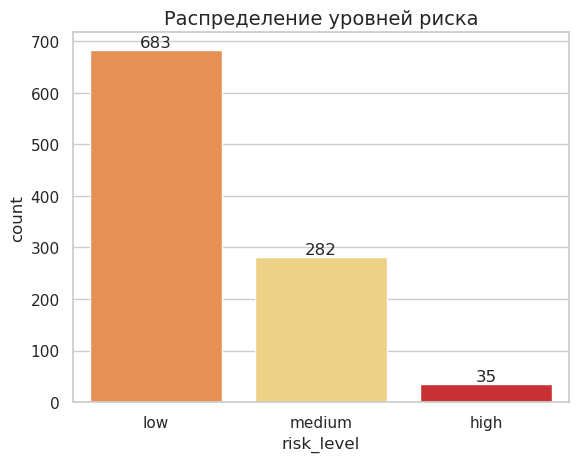

In [4]:
#Распределение уровней риска
sns.set_theme(style="whitegrid")
ax = sns.countplot(
    data=df, 
    x="risk_level", 
    order=risk_order,
    hue="risk_level", 
    palette="YlOrRd"
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.title("Распределение уровней риска", fontsize=14)
plt.show()

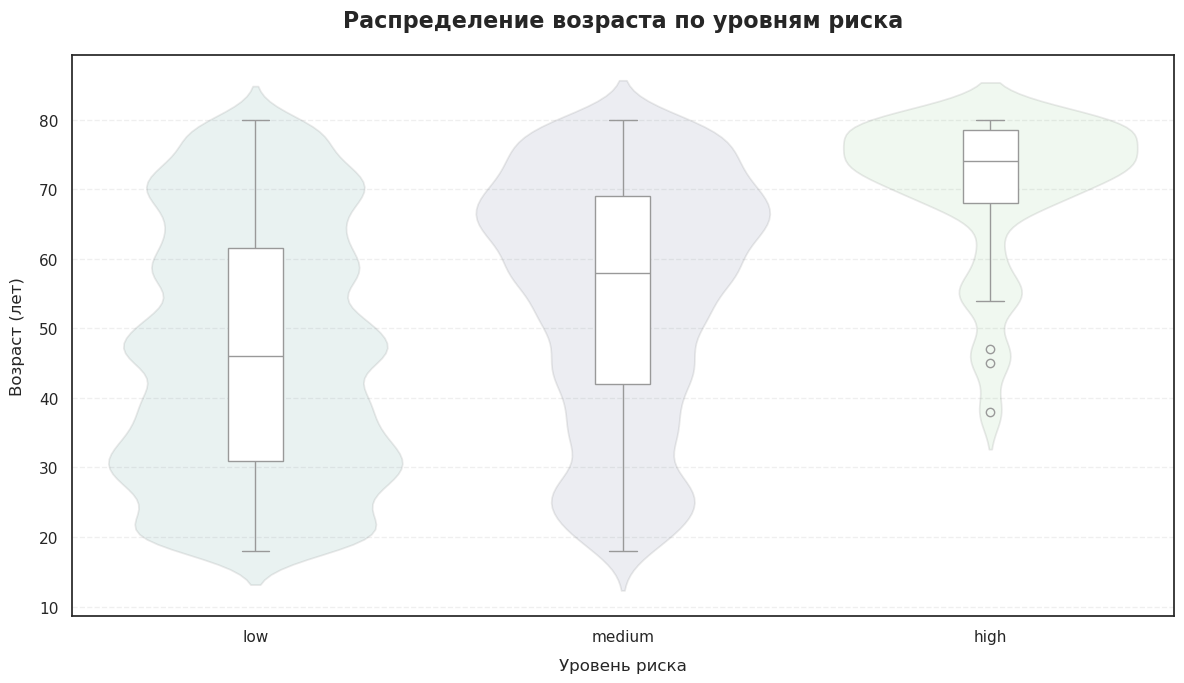

In [5]:
# Распределение возраста по уровням риска
sns.set_theme(style="white", palette="muted")
plt.figure(figsize=(12, 7))

# 1Boxplot
sns.boxplot(
    data=df, x="risk_level", y="age",
    width=0.15,
    color="white", 
    order=risk_order,
)

# Violinplot (эффект тени)
sns.violinplot(
    data=df, x="risk_level", y="age", 
    hue="risk_level", 
    palette="viridis",
    inner=None,      # Убираем внутренние элементы виолина
    alpha=0.1, 
    bw_adjust=.5, 
    legend=False
)

plt.title("Распределение возраста по уровням риска", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Уровень риска", fontsize=12, labelpad=10)
plt.ylabel("Возраст (лет)", fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

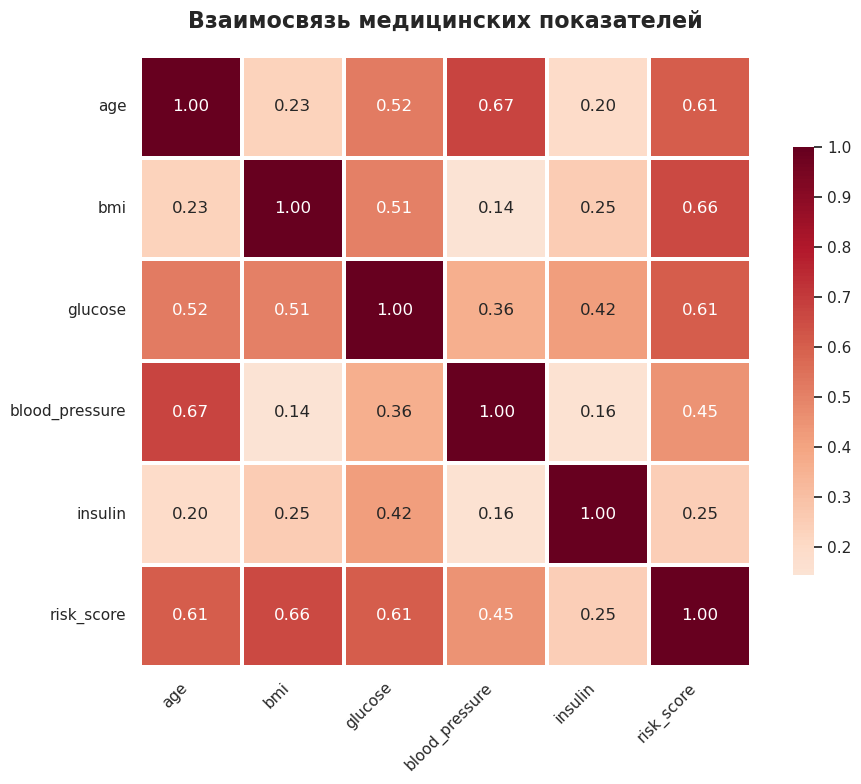

In [6]:
# Взаимосвязь медицинских показателей
cols = ["age", "bmi", "glucose", "blood_pressure", "insulin", "risk_score"]
corr = df[cols].corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', 
    center=0,
    square=True, 
    linewidths=1.5,
    cbar_kws={"shrink": .7},
    linecolor='white' 
)

plt.title("Взаимосвязь медицинских показателей", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()